In [2]:
import pandas as pd
import numpy as np

In [3]:
# =====================================================
# Load Dataset & Basic Preprocessing
# =====================================================

df = pd.read_csv('../Data/feature-columns.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)   

In [4]:
# 80% train, 20% test
split = int(len(df) * 0.8)

train = df.iloc[:split]
test  = df.iloc[split:]

print(f"Train: {train.index[0].date()} to {train.index[-1].date()}")
print(f"Test:  {test.index[0].date()} to {test.index[-1].date()}")
print(f"Train rows: {len(train)}, Test rows: {len(test)}")

Train: 2021-01-08 to 2025-01-02
Test:  2025-01-02 to 2025-12-31
Train rows: 174624, Test rows: 43656


In [5]:
X_train = train.drop(columns=['pickup_count','zone_data'])
y_train = train['pickup_count']

X_test = test.drop(columns=['pickup_count','zone_data'])
y_test = test['pickup_count']

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")

X_train shape: (174624, 22)
X_test shape:  (43656, 22)


In [6]:
from xgboost import XGBRegressor 

model = XGBRegressor( 
    n_estimators=350, 
    learning_rate=0.05, 
    max_depth=6, 
    subsample=0.8, 
    colsample_bytree=0.8, 
    random_state=42, 
    n_jobs=-1
) 

model.fit( 
    X_train, y_train, 
    eval_set=[(X_test, y_test)],
    verbose=50
)

y_pred = model.predict(X_test)

[0]	validation_0-rmse:40.19909
[50]	validation_0-rmse:11.10150
[100]	validation_0-rmse:10.70548
[150]	validation_0-rmse:10.67799
[200]	validation_0-rmse:10.36981
[250]	validation_0-rmse:10.21104
[300]	validation_0-rmse:10.06457
[349]	validation_0-rmse:9.95892


In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
accuracy = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.0f}")   
print(f"RMSE : {rmse:.0f}")   
print("R2  :", accuracy)

MAE  : 6
RMSE : 10
R2  : 0.9417980313301086


In [8]:
zone_test = test['zone_data']
results = X_test.copy()
results['actual'] = y_test
results['predicted'] = y_pred
results['zone'] = zone_test

for zone, group in results.groupby('zone'):
    mae_zone = mean_absolute_error(group['actual'], group['predicted'])
    print(f"{zone}: MAE = {mae_zone:.2f}")

Airport: MAE = 7.73
Downtown: MAE = 7.12
Midtown: MAE = 10.01
Suburb: MAE = 2.52
Uptown: MAE = 4.56


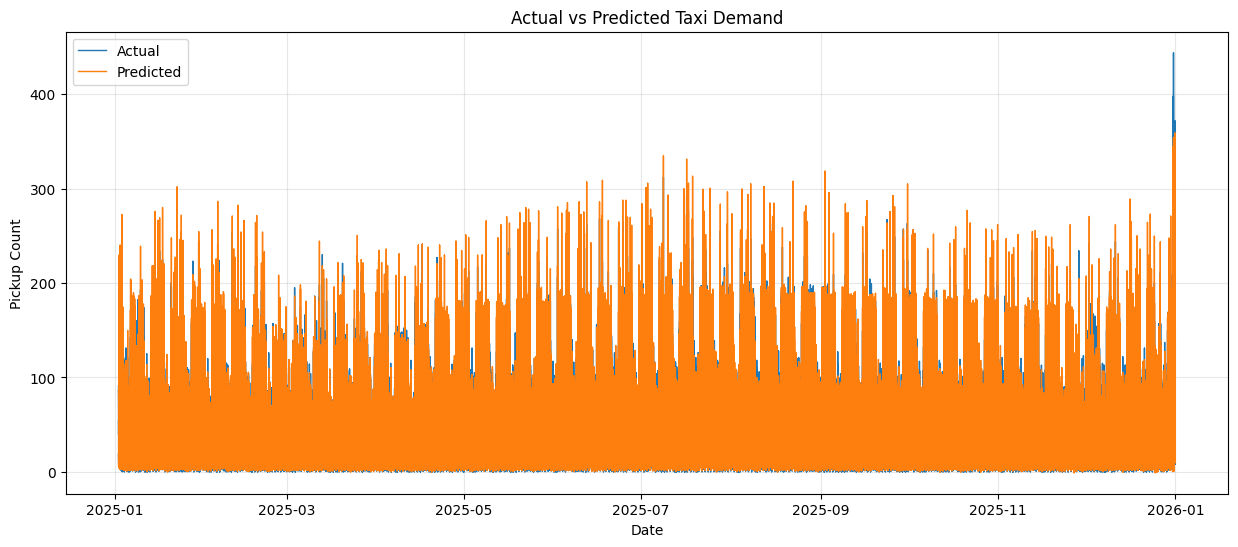

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

plt.plot(
    y_test.index,
    y_test.values,
    label="Actual",
    linewidth=1
)

plt.plot(
    y_test.index,
    y_pred,
    label="Predicted",
    linewidth=1
)

plt.title("Actual vs Predicted Taxi Demand")
plt.xlabel("Date")
plt.ylabel("Pickup Count")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [10]:
residuals = y_test.values - y_pred

residual_df = pd.DataFrame({
    "Zone": zone_test,
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Residual": residuals
}, index=y_test.index)

residual_df.head(24)

,Zone,Actual,Predicted,Residual
datetime,,,,
2025-01-02 04:00:00,Airport,91,86.100105,4.899895
2025-01-02 05:00:00,Airport,62,74.154961,-12.154961
2025-01-02 05:00:00,Downtown,39,46.029400,-7.029400
2025-01-02 05:00:00,Midtown,55,54.041924,0.958076
2025-01-02 05:00:00,Suburb,9,5.196582,3.803418
2025-01-02 05:00:00,Uptown,19,19.524368,-0.524368
2025-01-02 06:00:00,Suburb,11,11.332148,-0.332148
2025-01-02 06:00:00,Midtown,107,97.382065,9.617935
2025-01-02 06:00:00,Uptown,37,39.996014,-2.996014


In [11]:
importance = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(importance)

lag_168             0.418025
lag_1               0.161664
is_raining          0.134326
lag_24              0.062793
precipitation       0.048819
zone_Midtown        0.025605
is_weekend          0.024226
day_of_week         0.023743
is_holiday          0.017980
hour_cos            0.012900
zone_Downtown       0.009694
hour_sin            0.009426
zone_Uptown         0.009360
rolling_mean_168    0.007537
month_cos           0.006960
lag_3               0.005575
rolling_mean_24     0.005219
time_index          0.003960
temperature         0.003317
lag_2               0.003283
zone_Suburb         0.002967
month_sin           0.002620
dtype: float32


In [12]:
import joblib

# Model saved
joblib.dump(model, 'xgboost_model.pkl')
print("✅ Model saved successfully!")

feature_columns = list(X_train.columns)

joblib.dump(feature_columns, 'feature_columns.pkl')
print("Feature columns saved!")
print(feature_columns)  
print(f"\nTotal features: {len(feature_columns)}")

✅ Model saved successfully!
Feature columns saved!
['time_index', 'lag_1', 'lag_2', 'lag_3', 'lag_24', 'lag_168', 'rolling_mean_24', 'rolling_mean_168', 'hour_sin', 'hour_cos', 'day_of_week', 'is_weekend', 'month_sin', 'month_cos', 'temperature', 'precipitation', 'is_raining', 'is_holiday', 'zone_Downtown', 'zone_Midtown', 'zone_Suburb', 'zone_Uptown']

Total features: 22
